In [2]:
import numpy as np
import os
import xarray as xr
import glob
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import BoundaryNorm
import matplotlib.colors as mcolors
import dask.array as da
import pickle
from scipy.stats import t
import matplotlib.ticker as ticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.cm as cm
from scipy.stats import pearsonr

In [42]:
# my function

def calculate_horizontal_advection_single_gridpoint(u, v, q, lat, lon):

    R = 6371000.0   # Earth radius (m)
    
    seconds_to_day = 86400.0  # s/day

    # grid spacing (radians)
    
    lat_rad = np.radians(lat)
    
    lon_rad = np.radians(lon)
    
    delta_phi = lat_rad[1] - lat_rad[0]
    
    delta_lambda = lon_rad[1] - lon_rad[0]
    
    # meshgrid
    
    lon2d, lat2d = np.meshgrid(lon_rad, lat_rad)
    
    cos_lat = np.cos(lat2d)
    
    nlev = u.shape[0]
    
    dqdx = np.zeros(nlev)
        
    dqdy = np.zeros(nlev)
    
    # lon center point
    
    i = 1 
    
    # lat center point
    
    j = 1
    
    # Loop through each pressure level
    
    for k in range(u.shape[0]):
                    
        dqdx[k] = (q[k, i, 2] - q[k, i, 0]) / (2 * delta_lambda)
                
        dqdy[k] = (q[k, 2, j] - q[k, 0, j]) / (2 * delta_phi)
        
        dqdx[k] = dqdx[k] / (R * cos_lat[i, j]) 
        
        dqdy[k] = dqdy[k] / R 
                
    merid_adv = -(v[:, i, j] * dqdy) * seconds_to_day
    
    zonal_adv = -(u[:, i, j] * dqdx) * seconds_to_day
        
    return zonal_adv, merid_adv

In [45]:
# --- Test setup ---

lat = np.array([30, 30.25, 30.5])      # degrees

lon = np.array([-100, -99.75, -99.5])  # degrees

nlev = 1

u = np.ones((nlev, len(lat), len(lon)))

v = np.ones((nlev, len(lat), len(lon)))

# q = sin(lat) + cos(lon)

lat_rad = np.radians(lat)

lon_rad = np.radians(lon)

lon2d, lat2d = np.meshgrid(lon_rad, lat_rad)

q = (np.sin(lat2d) + np.cos(lon2d))[None, :, :]   # shape (nlev, lat, lon)

# --- Call function ---
zonal_adv, merid_adv = calculate_horizontal_advection_annie_fixed(u, v, q, lat, lon)

# --- Analytical expected solution at center point ---

R = 6371000.0

seconds_to_day = 86400.0

lat_c_rad = np.radians(lat[1])

lon_c_rad = np.radians(lon[1])

dqdx_exact = -np.sin(lon_c_rad) / (R * np.cos(lat_c_rad))

dqdy_exact = np.cos(lat_c_rad) / R

zonal_adv_expected = -1 * dqdx_exact * seconds_to_day

merid_adv_expected = -1 * dqdy_exact * seconds_to_day

# --- Compare ---
print("Zonal advection (computed):", zonal_adv[0])

print("Zonal advection (expected):", zonal_adv_expected)

print("Meridional advection (computed):", merid_adv[0])

print("Meridional advection (expected):", merid_adv_expected)

Zonal advection (computed): -0.015472305830784747
Zonal advection (expected): -0.015472354926038347
Meridional advection (computed): -0.011714825117638689
Meridional advection (expected): -0.011714862290010954


In [53]:
# --- Synthetic test data ---

nlev = 30          # vertical levels

nlat, nlon = 3, 3  # 3x3 patch

lat = np.array([30.0, 30.25, 30.5])   # degrees

lon = np.array([-100.0, -99.75, -99.5])

# synthetic wind fields

u = np.zeros((nlev, nlat, nlon))

v = np.zeros((nlev, nlat, nlon))

for k in range(nlev):
    
    u[k, :, :] = 5 + 0.5*k + 0.1*np.random.randn(nlat, nlon)  # m/s, increasing with height
    
    v[k, :, :] = 1.0 + 0.05*k + 0.1*np.random.randn(nlat, nlon)  # weak southerly wind

# synthetic q: exponentially decays with height

q = np.zeros((nlev, nlat, nlon))

for k in range(nlev):
    
    q[k, :, :] = np.exp(-k/2.0) * (0.01 + 0.001*np.random.randn(nlat, nlon))  # kg/kg

# run the function

zonal_adv, merid_adv = calculate_horizontal_advection_annie_fixed(u, v, q, lat, lon)

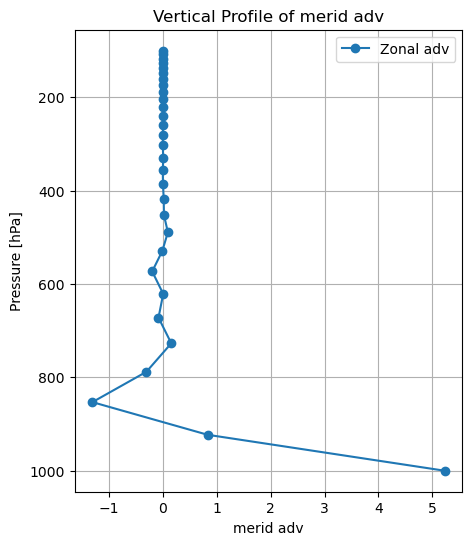

In [54]:
pressure = np.logspace(np.log10(1000), np.log10(100), num=nlev, dtype=int)

plt.figure(figsize=(5,6))

plt.plot(merid_adv * 1000, pressure, marker="o", label="Zonal adv")

plt.gca().invert_yaxis()   # put 1000 hPa at bottom, 50 hPa at top

plt.xlabel("merid adv")

plt.ylabel("Pressure [hPa]")

plt.title("Vertical Profile of merid adv")

plt.legend()

plt.grid(True)

plt.show()